In [1]:
#valor solucion entero: true true Best objective 4.371252893718e+07, best bound 4.371252893718e+07, gap 0.0000%
# true false: Best objective 4.371252893718e+07, best bound 4.371252893718e+07, gap 0.0000%
# false false: Best objective 4.371252893718e+07, best bound 4.371252893718e+07, gap 0.0000%

In [2]:
from modulo_input_modelo import crear_input, Transicion_flota_modelo, tam_bat
import pandas as pd
from gurobipy import Model, GRB, quicksum
import numpy as np

In [ ]:
# Lectura de parámetros iniciales, estado de la flota actual y su operación
datos = pd.read_excel('input_EPMTPQ.xlsx',sheet_name=None)

# Definición del Caso Base
params = {'fin_horizonte': True, 'presupuesto': [True,25000000], 'emisiones': True, 'contenedores': True, 'edad_media': True,
          'reduccion_anual_precio_bateria': 0.12, 'Precio_Elect_Noche': 0.073, 'Precio_Elect_Dia': 0.084,
          'rho_N': 0.75, 'Precio_diesel': 0.44, 'Periodos': 26, 'Tasa_redu_emisiones': 1/26,'mantenimiento_elec_ahorro': 6/10,
          'escenario': 0,'sensi_combus':[True,False]} # Caso Base

params_exp = params
L,CT,T,K,J_K,J_K_tilde,K_E,K_R,C,alpha,R,beta,f,s,kappa,mc,p,F,g,p_tilde,num_per,o,o_inv,o_techo,q,h,t1,a,e,e_tilde,t_F,Gamma,theta,theta_tilde,B,Theta,Theta_tilde,var_epsilon,c_tilde,costo_kwh,cost_bus_sin_bat,efic_bus,DA,epsilon,rho_N,PE_N = crear_input(datos,params_exp)

Costo de baterias Schmidt


In [4]:
# Determinar en que año ya se encuentra tod ala flota electrificada o el 50%
def indicadores(q,R, T, K_E, J_K, z, mo):
    anio_50 = None
    anio_100 = None
    total_flota = sum(q[r] for r in R)
    flag = True
    for t in T:
        num_buses = sum( z[k,t,j-1].x for k in K_E for j in J_K[k] if j != 0)
        if num_buses >= 0.5 * np.ceil(total_flota) and flag:
            anio_50 = t
            flag = False
        if num_buses == total_flota:
            anio_100 = t
            break
    indicadores = {'Funcion Objetivo': round(mo.ObjVal,3), 'Numero años 50 electrificado': anio_50, 'Numero años 100 electrificado': anio_100, 'Tiempo de Solucion': round(mo.Runtime,2)}
    return indicadores

In [ ]:
mo = Model()
mo.Params.OutputFlag = 1
# Variables
u = mo.addVars(CT,T,name='u',vtype='I', lb= 0) # I
v = mo.addVars(CT,T,name='v',vtype='I', lb= 0) # I
x = mo.addVars( K,T,name='x',vtype='I', lb= 0) # I
b = mo.addVars(T   ,name='b',vtype='C', lb= 0) # C
w_diesel = {}
w_energia = {}

u_tilde = mo.addVars(T,name='u',vtype='I', lb= 0) # I
v_tilde = mo.addVars(T,name='v',vtype='I', lb= 0) # I

if params['contenedores'] == False:
    u_tilde.ub = 0
    v_tilde.ub = 0

y = {}; [y.update(mo.addVars([k],T,[j]  , name= 'y',vtype= 'I', lb= 0)) for k in K for j in J_K[k] if j != 0]; # I
z = {}; [z.update(mo.addVars([k],T,[j-1], name= 'z',vtype= 'I', lb= 0)) for k in K for j in J_K[k] if j != 0]; # I
w = {}; [w.update(mo.addVars([k],R,T,[j], name= 'w',vtype= 'I', lb =0)) for k in K for j in J_K_tilde[k]    ]; # I
mo.update()
vars   = ['u','v','x','b','u_tilde','v_tilde','y','z','w']
# Funcion objetivo

w_diesel = mo.addVar(name='w_diesel',vtype='C', lb= 0) # C
w_energia = mo.addVar(name='w_energia',vtype='C', lb= 0) # C

mo.addConstr( w_diesel == 
        quicksum( 
                (beta**( (t_+1) -1) * (1/efic_bus[k]) * DA[r]) * w[k,r,t,j]
                for t_,t in enumerate(T) 
                for k in K if k not in K_E 
                for r in R 
                for j in range(0, (kappa[k]) +1) 
                )
        + 
        quicksum( 
                (beta**( num_per + i - 1 ) * (1/efic_bus[k]) * DA[r]) * w[k,r,t_F,j]
                for k in K if k not in K_E 
                for r in R 
                for j in range(0, (kappa[k]-1) +1)
                for i in range(1, (kappa[k]-j) +1)
                ), name='R-diesel_');
        
mo.addConstr( w_energia == 
        quicksum( 
                beta**( (t_+1) -1) * DA[r] *  
                ( 
                  quicksum( (1/efic_bus[k]) * w[k,r,t,j] for k in K_E if k not in K_R for j in range(0, (kappa[k]) +1) ) +
                  quicksum( (1/efic_bus[k]) * (1 + epsilon - (rho_N*epsilon) ) * w[k,r,t,j] for k in K_R for j in range(0, (kappa[k]) +1) )
                )
                for t_,t in enumerate(T) 
                for r in R
                )
        +
        quicksum( DA[r] *  
                ( 
                  quicksum( beta**( num_per + i - 1 ) * (1/efic_bus[k]) * w[k,r,t_F,j] 
                          for k in K_E if k not in K_R 
                          for j in range(0, (kappa[k]-1) +1)
                          for i in range(1, (kappa[k]-j) +1) )
                  +
                  quicksum( beta**( num_per + i - 1 ) * (1/efic_bus[k]) * (1 + epsilon - (rho_N*epsilon) ) * w[k,r,t_F,j] 
                          for k in K_R 
                          for j in range(0, (kappa[k]-1) +1)
                          for i in range(1, (kappa[k]-j) +1) )
                )
                for r in R
                ), name='R-energia_')
        
mo.setObjective(
            quicksum( beta**( (t_+1) -1) * quicksum( f[k,t] * x[k,t] 
                                          - quicksum( s[k,j] * y[k,t,j]  for j in range(1, (kappa[k]+1) +1))
                                          + quicksum( o_inv[k,r,t,j] * w[k,r,t,j] for r in R for j in range(0, (kappa[k]) +1))
                                          + mc[k,t] * z[k,t,alpha[k]]
                                        for k in K)  
                    for t_,t in enumerate(T) )
          
            +quicksum( beta**( (t_+1) -1) * quicksum( p[c] * u[c,t] + F * g[c] * v[c,t] for c in CT) for t_,t in enumerate(T) )
            +quicksum( beta**( (t_+1) -1) * p_tilde * u_tilde[t] for t_,t in enumerate(T) )
            
            +quicksum( beta**( num_per + i - 1 ) * o_inv[k,r,t_F,j+i] * w[k,r,t_F,j]
                      for k in K for r in R for j in range(0, (kappa[k]-1) +1) for i in range(1, (kappa[k]-j) +1) ) 
            - quicksum( beta**( num_per + kappa[k] - j ) * s[k,kappa[k]+1] * z[k,t_F,j] for k in K for j in range(0, (kappa[k]) +1) ) 
            + quicksum( beta**( num_per + alpha[k] - j - 1 ) * mc[k,t_F] * z[k,t_F,j] for k in K for j in range(0, (alpha[k]-1) +1 ) )
            + params['Precio_diesel']*w_diesel + params['Precio_Elect_Noche']* w_energia
            , GRB.MINIMIZE)
# Restricciones

mo.addConstrs( ( quicksum( w[k,r,t,j]  for k in K for j in range(0,kappa[k] + 1)) == q[r]  for r in R for t in T), name='R-2_');

mo.addConstrs( ( w[k,r,t,j] <= h[k,r,t,j] * z[k,t,j] for k in K for r in R for t in T for j in J_K_tilde[k] ), name='R-3_');

mo.addConstrs( ( quicksum( w[k,r,t,j]  for r in R) == z[k,t,j] for k in K for t in T for j in J_K_tilde[k] ), name='R-4_');

mo.addConstrs( ( x[k,t] == z[k,t,0] for k in K for t in T if t != t1), name='R-5_');

mo.addConstrs( ( x[k,t1] + a[k,0] == z[k,t1,0] for k in K ), name='R-6_');

mo.addConstrs( ( z[k,t,j] == z[k,t-1,j-1] - y[k,t,j] for k in K for t in T if t != t1 for j in J_K_tilde[k] if j != 0 ), name='R-7_');

mo.addConstrs( ( z[k,t1,j] == a[k,j] - y[k,t1,j] for k in K for j in J_K_tilde[k] if j != 0), name='R-8_');

mo.addConstrs( ( y[k,t,(kappa[k]+1)] == z[k,t-1,kappa[k]] for k in K for t in T if t != t1), name='R-9_');

mo.addConstrs( ( y[k,t1,(kappa[k]+1)] == a[k,kappa[k]+1] for k in K ), name='R-10_');

mo.addConstrs( ( v[c,t1] == e[c] + u[c,t1] for c in CT ), name='R-11_');

mo.addConstrs( (  v[c,t] == v[c,t-1] + u[c,t] for t in T if t != t1 for c in CT ), name='R-12_');

if params['edad_media']:
    mo.addConstr(  quicksum( j * z[k,t_F,j] for k in K for j in range(0,(kappa[k]) +1)) <= 
                    Gamma * quicksum( z[k,t_F,j] for k in K for j in range(0,(kappa[k]) +1)) , name='R-13_');

mo.addConstrs( ( v[c,t] + v[c_tilde,t] >= theta[c] * quicksum( z[k,t,j] for k in K_E if c in C[k] for j in range(0, (kappa[k]) +1)) 
                for c in CT if c != c_tilde for t in T ), name='R-14_');

mo.addConstrs( ( quicksum( f[k,t] * x[k,t] - quicksum( s[k,j] * y[k,t,j] for j in range(1, (kappa[k]+1) + 1)) for k in K)
            + quicksum( p[c] * u[c,t] for c in CT)
            + p_tilde * u_tilde[t] == b[t]   for t in T ), name='R-15_');

mo.addConstr(    v_tilde[t1] == e_tilde + u_tilde[t1] , name='R-16_');

mo.addConstrs( ( v_tilde[t] == v_tilde[t-1] + u_tilde[t] for t in T if t != t1 ), name='R-17');

mo.addConstrs( ( v[c_tilde,t] <= theta_tilde * v_tilde[t] for t in T ), name='R-18');

if params['presupuesto'][0]:
    mo.addConstr( quicksum( b[t] for t in T ) <= B, name='R-19_');

if params['emisiones']:
    mo.addConstrs( ( quicksum( var_epsilon[(k,j,r,l)] * w[k,r,t,j]  for k in K for j in range(0,kappa[k] + 1) for r in R) <= Theta[(l,t)] 
                for t in T for l in L ), name='R-20');

# mo.addConstrs( ( quicksum( g[c] * v[c,t] for c in DC) <= G for t in T if np.char.isnumeric(G) ), name='R-14_');

# mo.addConstrs( ( quicksum( v[c,t] for c in DC) <= H for t in T if np.char.isnumeric(H) ), name='R-15_');

#mo.Params.MIPGap = 0
mo.update()
mo.optimize()

#print(mo.Status)
#mo.computeIIS()
#mo.write('infactible.ilp')
  

Set parameter Username
Academic license - for non-commercial use only - expires 2026-03-19
Set parameter OutputFlag to value 1
Gurobi Optimizer version 12.0.2 build v12.0.2rc0 (win64 - Windows 10.0 (19045.2))

CPU model: Intel(R) Core(TM) i7-9700K CPU @ 3.60GHz, instruction set [SSE2|AVX|AVX2]
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Optimize a model with 22468 rows, 22206 columns and 111122 nonzeros
Model fingerprint: 0x6e3ede39
Coefficient statistics:
  Matrix range     [5e-02, 1e+06]
  Objective range  [7e-02, 8e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [1e+00, 7e+07]
Presolve removed 7897 rows and 7844 columns
Presolve time: 0.05s
Presolved: 14571 rows, 14362 columns, 71682 nonzeros

Concurrent LP optimizer: primal simplex, dual simplex, and barrier
Showing barrier log only...

Ordering time: 0.04s

Barrier statistics:
 AA' NZ     : 1.275e+05
 Factor NZ  : 3.165e+05 (roughly 14 MB of memory)
 Factor Ops : 1.557e+07 (less than 1 se

In [6]:
grafico_calor1 = {}
#grafico_calor1 = {(params['Precio_diesel'],params['Precio_Elect_Noche']): indicadores(q,R, T, K_E, J_K, z, mo)} #(disel,energia): 

In [ ]:
paso_diesel = 0.11
paso_energia = 0.001
diesel = np.arange(paso_diesel, 2+paso_diesel, paso_diesel) # https://es.globalpetrolprices.com/diesel_prices/
energia = np.arange(paso_energia, 1+paso_energia, paso_energia) # https://es.statista.com/estadisticas/635212/precios-de-la-electricidad-en-determinados-paises/
experimentos = [(d, e) for d in diesel for e in energia]

In [8]:
diesel.size*energia.size

200000

In [9]:
def actualizar(i,j,w_diesel, w_energia, mo):
    w_diesel.Obj = i
    w_energia.Obj = j
    mo.optimize()
    return mo, w_diesel, w_energia

In [10]:
from alive_progress import alive_bar
mo.Params.OutputFlag = 0

with alive_bar(diesel.size*energia.size, force_tty=True) as bar:
    for i,j in experimentos:
        mo, w_diesel, w_energia = actualizar(i,j,w_diesel, w_energia, mo)
        grafico_calor1[(i,j)] = indicadores(q,R,T,K_E,J_K,z,mo)
        bar()

|████████████████████████████████████████| 200000/200000 [100%] in 2:18:28.5 (2480000/200000 [40%] in 56:26 (~1:2in 57:41 (~1:2(~1(~1 90024/200000 [45%] in 1:04:22 (~1in 1:05:30 (~192242/200000 [46%] in 1:05:59 (~193687/200000 [47%] in 1:07:08 (~1(~196000/200000 [48%] in 1:08:51 (~197489/200000 [49%] in 1:09:55 (~1in 1:10:05 (~1 98866/200000 [49%] in 1:11:09 (~1in 1:11:26 (~1(~199686/200000 [50%] in 1:11:44 (~1(~1(~in 1:12:12 (~100579/200000 [50%] in 1:12:29 (~(~in 1:13:06 (~ 101435/200000 [51%] in 1:13:07 (~in 1:13:19 (~ 101775/200000 [51%] in 1:13:25 (~(~(~ 102726/200000 [51%] in 1:14:06 (~ 102755/200000 [51%] in 1:14:08 (~in 1:14:14 (~▅▃▁ 103062/200000 [52%] in 1:14:22 (~in 1:14:40 (~in 1:14:44 (~▅▃▁ 103592/200000 [52%] in 1:14:49 (~in 1:14:50 (~104000/200000 [52%] in 1:15:11 (~(~ 104428/200000 [52%] in 1:15:27 (~104476/200000 [52%] in 1:15:30 (~ 104626/200000 [52%] in 1:15:36 (~(~in 1:15:55 (~in 1:16:11 (~(~(~in 1:16:38 (~▆█▆ 106028/200000 [53%] in 1:16:41 (~in 1:16:43 (~106268/200

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

def graficar_heatmap(diccionario_resultados, variable, cmap='viridis', destacar_valor=None):
    """
    Genera un heatmap a partir de un diccionario cuyos keys son tuplas (diesel, energia)
    y cuyos valores son diccionarios con resultados para distintas variables.
    
    Parámetros:
    - diccionario_resultados: dict con claves (diesel, energia)
    - variable: str, nombre de la variable interna que se quiere graficar
    - cmap: str, nombre del mapa de colores de matplotlib (opcional)
    - destacar_valor: tuple (diesel, energia), valor a destacar con un recuadro en el gráfico
    """
    # Convertir el diccionario en DataFrame plano
    df = pd.DataFrame([
        {'diesel': k[0], 'energia': k[1], **v} 
        for k, v in diccionario_resultados.items()
    ])

    if variable not in df.columns:
        raise ValueError(f"La variable '{variable}' no está presente en los datos.")

    # Crear tabla pivot para el heatmap
    tabla = df.pivot(index='energia', columns='diesel', values=variable)
    
    # Obtener coordenadas para la imagen
    x_vals = tabla.columns.to_numpy()
    y_vals = tabla.index.to_numpy()
    
    plt.figure(figsize=(10, 8))
    heatmap = plt.imshow(tabla, aspect='auto', origin='lower', 
                         extent=[x_vals.min(), x_vals.max(), y_vals.min(), y_vals.max()],
                         cmap=cmap)

    plt.colorbar(heatmap, label=variable)
    plt.xlabel("Costo del diésel")
    plt.ylabel("Costo de la energía")
    plt.title(f"Heatmap de {variable}")

    # Dibujar recuadro si se proporciona un valor a destacar
    if destacar_valor:
        diesel_real, energia_real = destacar_valor

        # Calcular tamaño del paso
        dx = np.diff(x_vals).mean()
        dy = np.diff(y_vals).mean()

        # Crear recuadro
        rect = patches.Rectangle(
            (diesel_real - dx/2, energia_real - dy/2),  # esquina inferior izquierda
            dx, dy, linewidth=2, edgecolor='red', facecolor='none'
        )
        plt.gca().add_patch(rect)

    plt.tight_layout()
    plt.show()



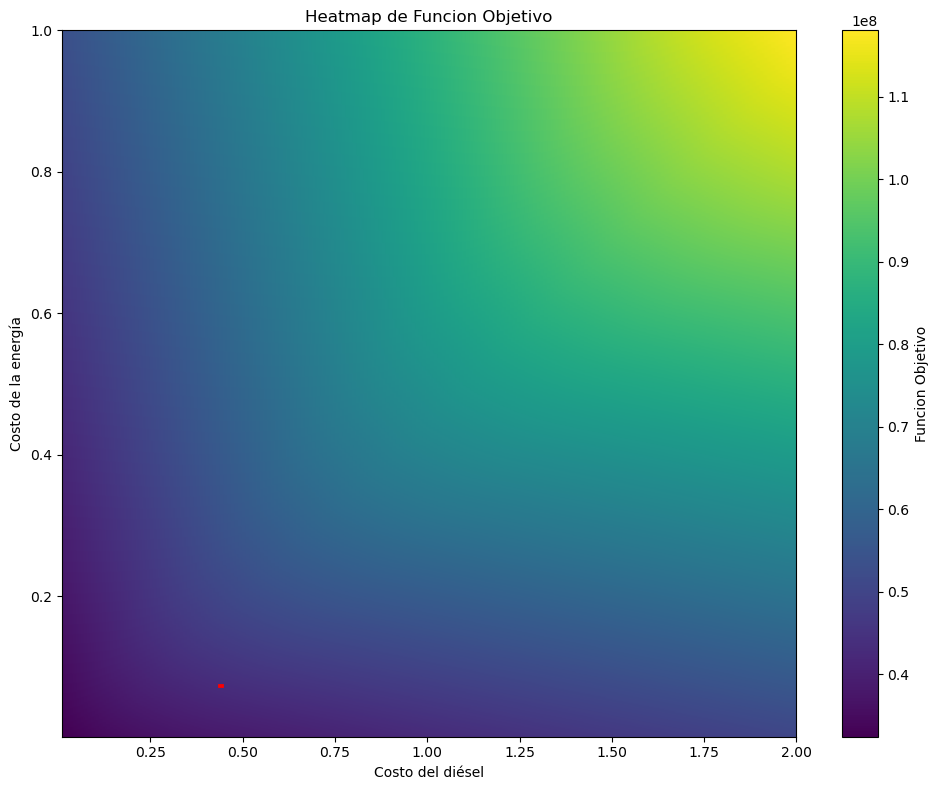

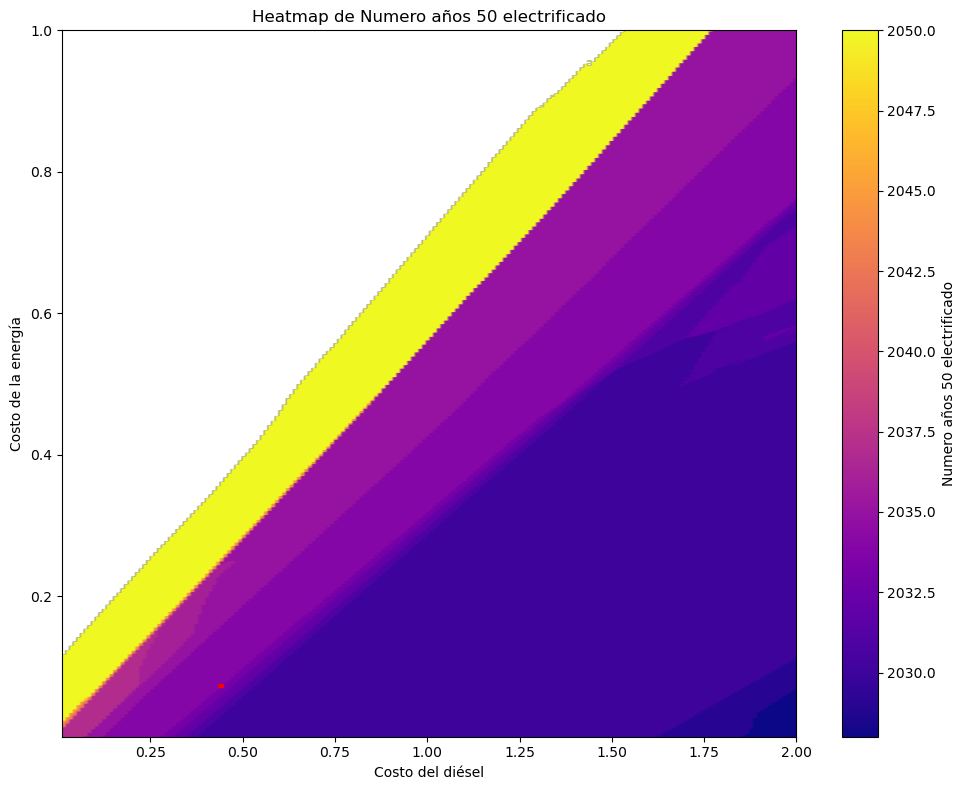

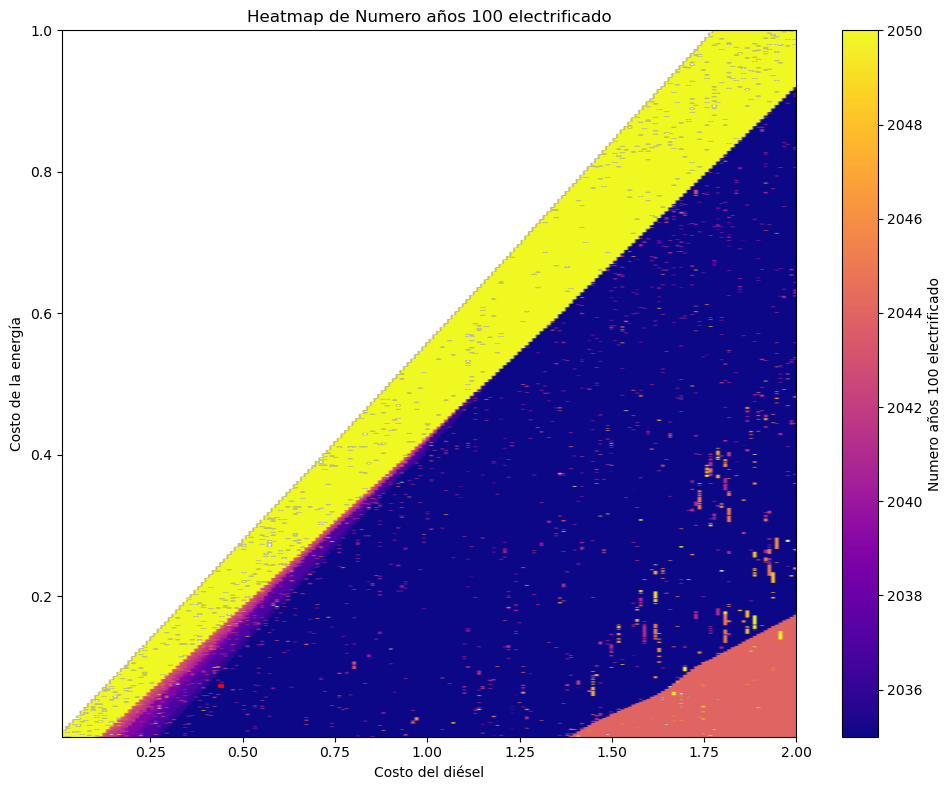

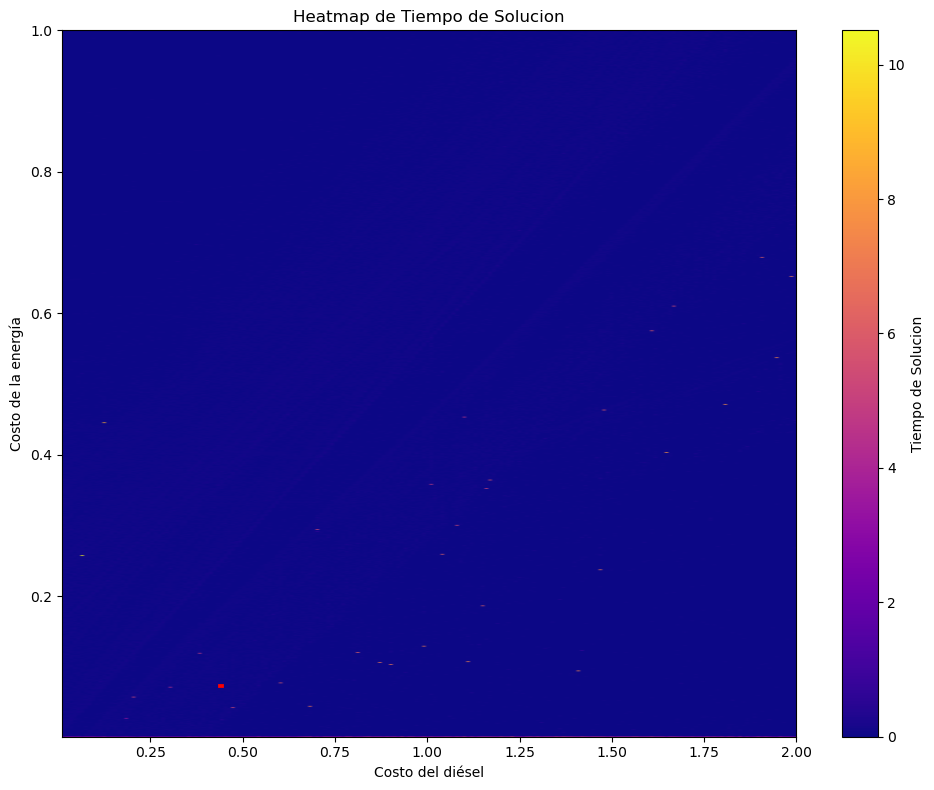

In [12]:
graficar_heatmap(grafico_calor1, 'Funcion Objetivo',destacar_valor=(0.44, 0.073))
graficar_heatmap(grafico_calor1, 'Numero años 50 electrificado', cmap='plasma',destacar_valor=(0.44, 0.073))
graficar_heatmap(grafico_calor1, 'Numero años 100 electrificado', cmap='plasma',destacar_valor=(0.44, 0.073))
graficar_heatmap(grafico_calor1, 'Tiempo de Solucion', cmap='plasma',destacar_valor=(0.44, 0.073))

In [13]:
import json

def guardar_resultados_json(diccionario, ruta_archivo):
    # Convertir claves de tupla a string para poder serializar en JSON
    serializable_dict = {
        f"{k[0]:.5f},{k[1]:.5f}": v for k, v in diccionario.items()
    }
    with open(ruta_archivo, 'w') as f:
        json.dump(serializable_dict, f, indent=2)
        
def cargar_resultados_json(ruta_archivo):
    with open(ruta_archivo, 'r') as f:
        raw_dict = json.load(f)
    
    # Convertir claves de string de nuevo a tupla de floats
    parsed_dict = {
        tuple(map(float, k.split(','))): v for k, v in raw_dict.items()
    }
    return parsed_dict

In [ ]:
# Guardar
guardar_resultados_json(grafico_calor1, "resultados_guardados_con_restr_emisiones_INT.json")

# Más adelante... cargar
#resultados_recuperados = cargar_resultados_json("resultados_guardados_sin_restr_emisiones.json")
